In [11]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
try:
    stopwords.words('english')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')
    print("Download complete.")


# Load the dataset
try:
    df = pd.read_csv('bida-7.csv')
    print("File 'bida-7.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'bida-7.csv' not found. Make sure it's in the same folder as your notebook.")
    raise


File 'bida-7.csv' loaded successfully.


In [13]:
# Drop rows where the review text or rating is missing
df.dropna(subset=['reviews.text', 'reviews.rating'], inplace=True)


# Combine review title and text for a complete feature
df['full_review'] = (
    df['reviews.title'].fillna('') + ' ' +
    df['reviews.text'].fillna('')
)


In [14]:
# Function to map star ratings (1-5) to sentiment labels
def map_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'


df['sentiment'] = df['reviews.rating'].apply(map_sentiment)

print("Sentiment labels created.")



Sentiment labels created.


In [15]:
# 2. Preprocess the Text
stop_words = set(stopwords.words('english'))


def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation/numbers
    words = text.split()

    # Remove stopwords
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return ' '.join(filtered_words)


df['cleaned_review'] = df['full_review'].apply(preprocess_text)

print("Text preprocessing complete.")


Text preprocessing complete.


In [16]:
# 3. Build and Train the Naïve Bayes Model
X = df['cleaned_review']
y = df['sentiment']


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Vectorize the text data
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Text data vectorized.")


# Initialize and train the classifier
model = MultinomialNB()

model.fit(X_train_vec, y_train)

print("Model training complete.")



Text data vectorized.
Model training complete.


In [8]:
# 4. Evaluate the Model
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))


print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['negative', 'neutral', 'positive']
)


--- Model Evaluation ---
Accuracy: 88.56%

Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.27      0.36        15
     neutral       0.86      0.48      0.62        25
    positive       0.90      0.98      0.94       196

    accuracy                           0.89       236
   macro avg       0.78      0.58      0.64       236
weighted avg       0.87      0.89      0.87       236


Confusion Matrix:


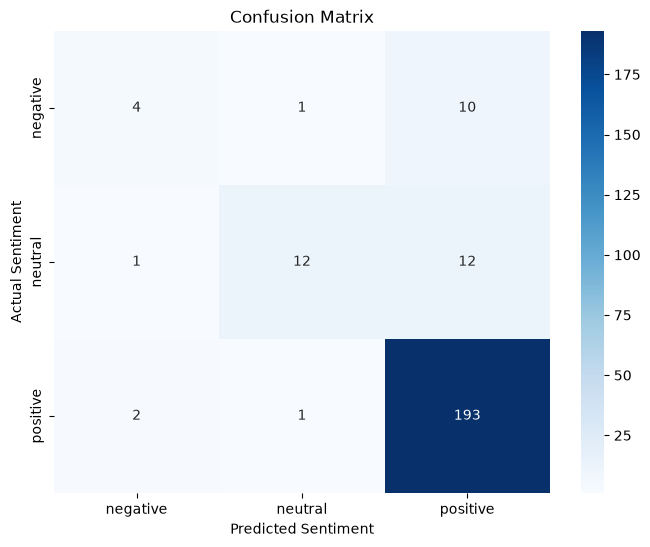

In [17]:

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix')

plt.show()